In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from organograph.mesh.OrganoidMesh import OrganoidMesh
from organograph.mesh.hks import compute_hks
from organograph.mesh.curvature import compute_gaussian_curvature, integrate_gaussian_curvature, compute_gaussian_curvature_fixed_time, compute_gaussian_curvature_adaptive_fixed_time
from organograph.plotting.meshes import *

In [2]:
NOTEBOOK_DIR = Path.cwd().resolve()

MESH_DATA_DIR = os.path.join(
    NOTEBOOK_DIR, "..", "..", "NicoleData", "20251201", "fractal_output"
)

TIMEPOINT = "day4p5"
WELL = "B03"

MESH_DIR = (
    Path(MESH_DATA_DIR)
    / TIMEPOINT
    / "251130R0.zarr"
    / WELL[0]           # "B"
    / WELL[1:]          # "03"
    / "2_zillum_registered"
    / "meshes"
    / "nnorg_corrected_annotated_by_projection"
)


# MESH_DATA_DIR = os.path.join(
#     NOTEBOOK_DIR, "..", "..", "NicoleData", "20250929", "fractal_output"
# )

# TIMEPOINT = "day4"
# WELL = "A05"

# MESH_DIR = (
#     Path(MESH_DATA_DIR)
#     / TIMEPOINT
#     / "r0.zarr"
#     / WELL[0]           # "B"
#     / WELL[1:]          # "03"
#     / "0_fused_zillum_registered"
#     / "meshes"
#     / "nnorg_linked_multi_annotated_class"
# )

print("MESH_DATA_DIR =", MESH_DATA_DIR)
print("TIMEPOINT     =", TIMEPOINT)
print("WELL          =", WELL)
print("MESH_DIR      =", MESH_DIR)

mesh_paths = sorted(MESH_DIR.glob("*.vtp"))
print(f"Found {len(mesh_paths)} organoid meshes")

MESH_DATA_DIR = /home/fmoller/Projects/LearningOrganoids/OrganoGraph/notebooks/../../NicoleData/20251201/fractal_output
TIMEPOINT     = day4p5
WELL          = B03
MESH_DIR      = /home/fmoller/Projects/LearningOrganoids/OrganoGraph/notebooks/../../NicoleData/20251201/fractal_output/day4p5/251130R0.zarr/B/03/2_zillum_registered/meshes/nnorg_corrected_annotated_by_projection
Found 104 organoid meshes


In [3]:
def mean_edge_length(mesh):
    """
    Compute the mean unique edge length of a triangular mesh.
    """
    v = np.asarray(mesh.v, dtype=float)
    f = np.asarray(mesh.f, dtype=np.int64)

    # collect all triangle edges
    edges = np.vstack([
        f[:, [0, 1]],
        f[:, [1, 2]],
        f[:, [2, 0]],
    ])

    # sort each edge so (i,j) and (j,i) are treated the same
    edges = np.sort(edges, axis=1)

    # keep unique edges only
    edges = np.unique(edges, axis=0)

    # compute lengths
    lengths = np.linalg.norm(v[edges[:, 0]] - v[edges[:, 1]], axis=1)
    return float(np.mean(lengths))


In [4]:
rows = []

for mesh_path in mesh_paths:
    org_id = mesh_path.stem
    print(f"Processing organoid {org_id} ...")

    try:
        # --- Load + normalize mesh ---
        mesh = OrganoidMesh(str(mesh_path))
        mesh.normalize_inplace()
        mesh._eig_decomp()

        # --- Curvature ---
        K_fit = compute_gaussian_curvature(mesh)
        K_fixed = compute_gaussian_curvature_fixed_time(mesh, c_h2=(25.0, 35.0, 45.0),)

        total_K_fit, info_fit = integrate_gaussian_curvature(
            mesh,
            K_fit,
            return_details=True,
        )

        total_K_fixed, info_fixed = integrate_gaussian_curvature(
            mesh,
            K_fixed, 
            return_details=True,
        )

        K_adapt, dbg_adapt = compute_gaussian_curvature_adaptive_fixed_time(
            mesh,
            threshold_factor=1.02,
            return_debug=True,
        )

        total_K_adapt, info_adapt = integrate_gaussian_curvature(
            mesh,
            K_adapt,
            return_details=True,
        )

        # --- Resolution proxy ---
        h_mean = mean_edge_length(mesh)

        rows.append({
            "org_id": org_id,
            "mean_edge_length": h_mean,

            # --- fit-based ---
            "total_K_fit": total_K_fit,
            "error_fit": info_fit["error_to_4pi"],
            "rel_error_fit": info_fit["relative_error_to_4pi"],
            "chi_fit": info_fit["estimated_euler_characteristic"],

            # --- fixed-time ---
            "total_K_fixed": total_K_fixed,
            "error_fixed": info_fixed["error_to_4pi"],
            "rel_error_fixed": info_fixed["relative_error_to_4pi"],
            "chi_fixed": info_fixed["estimated_euler_characteristic"],

            # --- fixed-time ---
            "total_K_adapt": total_K_adapt,
            "error_adapt": info_adapt["error_to_4pi"],
            "rel_error_adapt": info_adapt["relative_error_to_4pi"],
            "chi_adapt": info_adapt["estimated_euler_characteristic"],
        })

    except Exception as e:
        print(f"  -> failed for {org_id}: {e}")
        rows.append({
            "org_id": org_id,
            "mean_edge_length": np.nan,

            "total_K_fit": np.nan,
            "error_fit": np.nan,
            "rel_error_fit": np.nan,
            "chi_fit": np.nan,

            "total_K_fixed": np.nan,
            "error_fixed": np.nan,
            "rel_error_fixed": np.nan,
            "chi_fixed": np.nan,

            "total_K_adapt": np.nan,
            "error_adapt": np.nan,
            "rel_error_adapt": np.nan,
            "chi_adapt": np.nan,
        })

df_curv = pd.DataFrame(rows).sort_values("org_id").reset_index(drop=True)

display(df_curv)

Processing organoid 10 ...
Processing organoid 104 ...
Processing organoid 106 ...
Processing organoid 110 ...
Processing organoid 112 ...
Processing organoid 114 ...
Processing organoid 117 ...
Processing organoid 119 ...
Processing organoid 12 ...
Processing organoid 120 ...
Processing organoid 124 ...
Processing organoid 125 ...
Processing organoid 126 ...
Processing organoid 127 ...
Processing organoid 128 ...
Processing organoid 129 ...
Processing organoid 13 ...
Processing organoid 130 ...
Processing organoid 133 ...
Processing organoid 135 ...
Processing organoid 137 ...
Processing organoid 138 ...
Processing organoid 139 ...
Processing organoid 14 ...
Processing organoid 142 ...
Processing organoid 144 ...
Processing organoid 146 ...
Processing organoid 148 ...
Processing organoid 149 ...
Processing organoid 15 ...
Processing organoid 150 ...
Processing organoid 151 ...
Processing organoid 154 ...
Processing organoid 155 ...
Processing organoid 156 ...
Processing organoid 157 .

,org_id,mean_edge_length,total_K_fit,error_fit,rel_error_fit,chi_fit,total_K_fixed,error_fixed,rel_error_fixed,chi_fixed,total_K_adapt,error_adapt,rel_error_adapt,chi_adapt
0,10,0.123526,16.176678,3.610308,0.287299,2.574598,15.239834,2.673463,0.212747,2.425495,12.566371,0.000000e+00,0.000000e+00,2.0
1,104,0.104527,13.970175,1.403804,0.111711,2.223422,14.707519,2.141149,0.170387,2.340774,12.566371,0.000000e+00,0.000000e+00,2.0
2,106,0.148001,14.481770,1.915399,0.152423,2.304845,15.289609,2.723239,0.216708,2.433417,12.566371,1.776357e-15,1.413580e-16,2.0
3,110,0.150969,14.220756,1.654385,0.131652,2.263304,14.732494,2.166123,0.172375,2.344749,12.566371,0.000000e+00,0.000000e+00,2.0
4,112,0.096101,13.817475,1.251104,0.099560,2.199119,14.891067,2.324696,0.184993,2.369987,12.566371,0.000000e+00,0.000000e+00,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,93,0.112904,14.703441,2.137070,0.170063,2.340125,14.414457,1.848087,0.147066,2.294132,12.566371,0.000000e+00,0.000000e+00,2.0
100,94,0.160932,19.245076,6.678705,0.531474,3.062949,15.246605,2.680234,0.213286,2.426572,12.566371,0.000000e+00,0.000000e+00,2.0
101,95,0.202524,20.268147,7.701777,0.612888,3.225776,16.515558,3.949187,0.314266,2.628533,12.566371,-1.776357e-15,-1.413580e-16,2.0
102,97,0.180060,18.028322,5.461951,0.434648,2.869297,15.270804,2.704433,0.215212,2.430424,12.566371,0.000000e+00,0.000000e+00,2.0


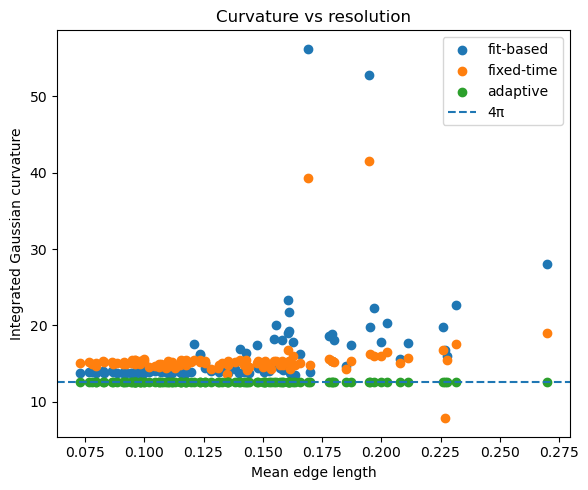

In [5]:

plt.figure(figsize=(6,5))

plt.scatter(df_curv["mean_edge_length"], df_curv["total_K_fit"], label="fit-based")
plt.scatter(df_curv["mean_edge_length"], df_curv["total_K_fixed"], label="fixed-time")
plt.scatter(df_curv["mean_edge_length"], df_curv["total_K_adapt"], label="adaptive")

plt.axhline(4.0 * np.pi, linestyle="--", label="4π")

plt.xlabel("Mean edge length")
plt.ylabel("Integrated Gaussian curvature")
plt.legend()
plt.title("Curvature vs resolution")
plt.tight_layout()
plt.show()